# Utvidelse 06 — Land/regioner og overføringsbegrensninger

Hovednotebooken behandler «Europa» som ett knutepunkt («copperplate»). I virkeligheten må kraft flyte gjennom **HVDC-kabler, AC-interkonnektorer og interne flaskehalser**.

Vi bygger en minimal flerregion-modell med fire soner:

- **NORDIC** (NO/SE/FI): mye vannkraft, vind, lite sol.
- **DE+BENELUX**: stor last, mye vind/sol, lite firm.
- **IBERIA** (ES/PT): mye sol/vind, godt isolert fra resten.
- **ALPS+IT** (CH/AT/IT/FR-syd): vannmagasin, kjernekraft.

Hver sone får residualbehov og tilgjengelige ressurser, og vi sjekker om interkonnektor-kapasitetene er nok til å balansere.


In [1]:
from __future__ import annotations
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd()
candidates = [HERE / "data" / "defaults.json", HERE.parent.parent / "data" / "defaults.json", HERE.parent / "data" / "defaults.json"]
defaults = json.loads(next(p for p in candidates if p.exists()).read_text())["defaults"]


## Sonebalanse under Dunkelflaute

Tall under er pedagogiske GW-størrelser, ikke tidsoppløste markedssimuleringer.


In [2]:
zones = pd.DataFrame([
    {"zone": "NORDIC",       "load_GW":  60, "firm_GW":  55, "vre_dunkelflaute_GW": 10},
    {"zone": "DE+BENELUX",   "load_GW": 120, "firm_GW":  35, "vre_dunkelflaute_GW": 15},
    {"zone": "IBERIA",       "load_GW":  45, "firm_GW":  20, "vre_dunkelflaute_GW": 12},
    {"zone": "ALPS+IT",      "load_GW":  90, "firm_GW":  60, "vre_dunkelflaute_GW":  8},
])
zones["balance_GW"] = zones["firm_GW"] + zones["vre_dunkelflaute_GW"] - zones["load_GW"]
zones


,zone,load_GW,firm_GW,vre_dunkelflaute_GW,balance_GW
0,NORDIC,60,55,10,5
1,DE+BENELUX,120,35,15,-70
2,IBERIA,45,20,12,-13
3,ALPS+IT,90,60,8,-22


Negativ `balance_GW` = sonen trenger import. Positiv = sonen kan eksportere.

## Interkonnektor-kapasiteter

Pedagogiske 2025-tall, omtrentlig nivå (NTC):


In [3]:
links = pd.DataFrame([
    {"from": "NORDIC",     "to": "DE+BENELUX", "ntc_GW": 8.5},
    {"from": "NORDIC",     "to": "ALPS+IT",    "ntc_GW": 0.0},
    {"from": "ALPS+IT",    "to": "DE+BENELUX", "ntc_GW": 14.0},
    {"from": "IBERIA",     "to": "DE+BENELUX", "ntc_GW": 5.0},  # via FR
    {"from": "IBERIA",     "to": "ALPS+IT",    "ntc_GW": 3.0},
])
links


,from,to,ntc_GW
0,NORDIC,DE+BENELUX,8.5
1,NORDIC,ALPS+IT,0.0
2,ALPS+IT,DE+BENELUX,14.0
3,IBERIA,DE+BENELUX,5.0
4,IBERIA,ALPS+IT,3.0


## Enkel greedy-flyt

Vi lar overskuddssoner sende til underskuddssoner langs hver linje, begrenset av NTC. Dette er **ikke** OPF; det er en intuisjons-test.


In [4]:
def settle(zones: pd.DataFrame, links: pd.DataFrame):
    bal = zones.set_index("zone")["balance_GW"].copy().astype(float)
    flows = []
    for _, link in links.iterrows():
        a, b, cap = link["from"], link["to"], link["ntc_GW"]
        if bal[a] > 0 and bal[b] < 0:
            send = min(bal[a], -bal[b], cap)
            bal[a] -= send
            bal[b] += send
            flows.append({"from": a, "to": b, "flow_GW": send})
        elif bal[b] > 0 and bal[a] < 0:
            send = min(bal[b], -bal[a], cap)
            bal[b] -= send
            bal[a] += send
            flows.append({"from": b, "to": a, "flow_GW": send})
    return bal, pd.DataFrame(flows)

post_balance, flows = settle(zones, links)
print("Sone-balanse etter overføring (negativ = batteri/DR/load shed nødvendig):")
print(post_balance)
print()
print("Flyt brukt:")
print(flows)
print()
print(f"Samlet ubalansert effektmangel: {-post_balance[post_balance < 0].sum():.1f} GW")


Sone-balanse etter overforing (negativ = batteri/DR/load shed nodvendig):
zone
NORDIC         0.0
DE+BENELUX   -65.0
IBERIA       -13.0
ALPS+IT      -22.0
Name: balance_GW, dtype: float64

Flyt brukt:
     from          to  flow_GW
0  NORDIC  DE+BENELUX      5.0

Samlet ubalansert effektmangel: 100.0 GW


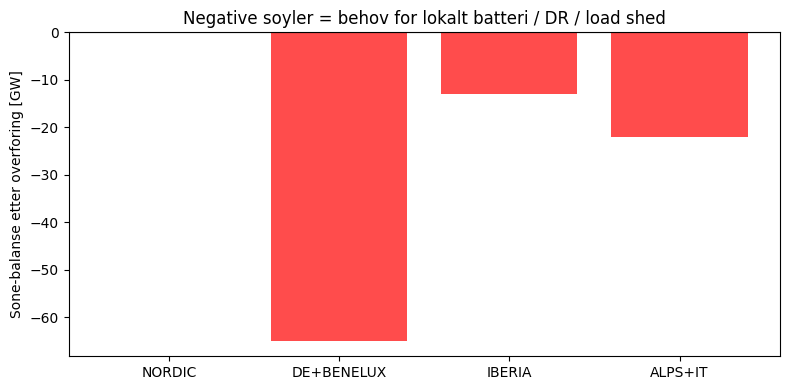

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["red" if v < 0 else "green" for v in post_balance.values]
ax.bar(post_balance.index, post_balance.values, color=colors, alpha=0.7)
ax.axhline(0, color="black")
ax.set_ylabel("Sone-balanse etter overføring [GW]")
ax.set_title("Negative søyler = behov for lokalt batteri / DR / load shed")
plt.tight_layout()
plt.show()


## Læring

- Selv om den **europeiske summen** er en bestemt residual gap, er den **lokalt fordelt skjevt** — DE+BENELUX er typisk underskuddssone, NORDIC og ALPS+IT er overskuddssoner.
- Tilgjengelig **NTC** er ofte mindre enn sonens overskudd. Dermed «strander» fleksibilitet og batterier må bygges **lokalt** der det mangler, ikke der det er billigst.
- Konklusjon: **kabel-utbygging** er ofte billigere per levert MWh enn batteri-utbygging i underskuddssoner — men har lengre ledetid og politisk friksjon.
